In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

/data/ll2531/venv/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
with open("processed_data_pkl/imputed_training_data.pkl", "rb") as f:
    traffic_dic = pickle.load(f)

with open("processed_data_pkl/weather_global_2014_2025.pkl", "rb") as f:
    weather = pickle.load(f)

air_qual = pd.read_csv("online_data/air_qual/air_qual.csv")

In [3]:
air_qual.drop(columns=["aerosol_optical_depth ()", "dust (μg/m³)"], inplace=True)
air_qual.dropna(inplace=True)
air_qual.reset_index(inplace=True, drop=True)

In [4]:
air_qual["time"] = pd.to_datetime(air_qual["time"], errors="coerce")
weather["timestamp"] = pd.to_datetime(weather["timestamp"], errors="coerce")

weather = weather[weather["timestamp"].isin(air_qual["time"])]
weather.reset_index(inplace=True, drop=True)

In [5]:
dataset = pd.concat([weather, air_qual], axis=1)
dataset.drop(columns=["time"], inplace=True)

# setting up the graph

In [6]:
import networkx as nx
import torch
from torch_geometric.utils import to_networkx
from torch_geometric.nn import GCNConv
from torch.nn import Linear
import geopy.distance
from torch_geometric.data import Data


/data/ll2531/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
G = nx.DiGraph()

for sensor_id, directions in traffic_dic.items():
    for direction, df in directions.items():
        origin_lat = df["latitude"].iloc[0]
        origin_lon = df["longitude"].iloc[0]

        G.add_node(sensor_id, pos=(origin_lon, origin_lat))
        
        for sensor_id_2, directions_2 in traffic_dic.items():
            if sensor_id == sensor_id_2:
                continue

            for direction_2, df_2 in directions_2.items():
                target_lat = df_2["latitude"].iloc[0]
                target_lon = df_2["longitude"].iloc[0]
                
                distance_m = geopy.distance.geodesic(
                    (origin_lat, origin_lon), 
                    (target_lat, target_lon)
                ).m

                if distance_m < 1000:
                    G.add_edge(
                        sensor_id, 
                        sensor_id_2, 
                        distance=distance_m, 
                        dir=direction
                    )

In [8]:
manual_edges = [(11,23), (9,22), (9,23), (1,12), (2,14), (3,14),(4,14), (5,15), (8,20), (6,19), (6,16), (8,19), (7,20), (7,19), (6,5), (17,14), (15,14), (16,14)]

In [9]:
import geopy.distance

node_positions = nx.get_node_attributes(G, "pos")

for source, target in manual_edges:
    lon1, lat1 = node_positions[source]
    lon2, lat2 = node_positions[target]

    distance_m = geopy.distance.geodesic((lat1, lon1), (lat2, lon2)).m
    G.add_edge(source, target, distance=distance_m)

In [10]:
sensor_ids = list(G.nodes())
node_map = {sid: idx for idx, sid in enumerate(sensor_ids)}
num_nodes = len(sensor_ids)

sample_df = list(traffic_dic[sensor_ids[0]].values())[0]

exclude_cols = ['latitude', 'longitude', 'timestamp', 'time', 'miles', "avtime", "hour"]
base_features = [col for col in sample_df.columns if col not in exclude_cols]

time_features = ['hour_sin', 'hour_cos', 'day_sin', 'day_cos']
all_features = base_features + time_features

num_timestamps = len(sample_df)
num_features = len(all_features)

x_tensor = torch.zeros((num_nodes, num_features, num_timestamps), dtype=torch.float)

for sensor_id in sensor_ids:
    node_idx = node_map[sensor_id]
    traffic_df = list(traffic_dic[sensor_id].values())[0].copy()
    
    traffic_df['timestamp'] = pd.to_datetime(traffic_df['timestamp'])
    
    traffic_df['hour_sin'] = np.sin(2 * np.pi * traffic_df['timestamp'].dt.hour / 24.0)
    traffic_df['hour_cos'] = np.cos(2 * np.pi * traffic_df['timestamp'].dt.hour / 24.0)
    traffic_df['day_sin'] = np.sin(2 * np.pi * traffic_df['timestamp'].dt.dayofweek / 7.0)
    traffic_df['day_cos'] = np.cos(2 * np.pi * traffic_df['timestamp'].dt.dayofweek / 7.0)
    traffic_df["count_imputed"] = traffic_df["count_imputed"].apply(lambda x: 0 if x == False else 1)
    traffic_features_matrix = traffic_df[all_features].values.T
    x_tensor[node_idx, :, :] = torch.tensor(traffic_features_matrix, dtype=torch.float)

edge_list = []
edge_attr_list = []
for u, v, data in G.edges(data=True):
    edge_list.append([node_map[u], node_map[v]])
    edge_attr_list.append([data['distance']])

edge_index = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
edge_attr = torch.tensor(edge_attr_list, dtype=torch.float)

pyg_dataset = Data(x=x_tensor, edge_index=edge_index, edge_attr=edge_attr)

In [11]:
import plotly.graph_objects as go

num_nodes = len(node_map)
coords_traffic = np.zeros((num_nodes, 2))

for sensor_id, node_idx in node_map.items():
    lon, lat = G.nodes[sensor_id]['pos']
    coords_traffic[node_idx, 0] = lon
    coords_traffic[node_idx, 1] = lat

edge_t_to_t = pyg_dataset.edge_index


def visualize_traffic_spatial_graph(coords_traffic, edge_t_to_t, mapbox_style="carto-positron"):
    """
    Visualizes the traffic sensor spatial graph directly on a map using Plotly Scattermapbox.
    """
    fig = go.Figure()

    # --- DRAW TRAFFIC-TO-TRAFFIC EDGES ---
    t_edge_lon, t_edge_lat = [], []
    t_start_nodes = edge_t_to_t[0].numpy()
    t_end_nodes = edge_t_to_t[1].numpy()
    
    for src, dst in zip(t_start_nodes, t_end_nodes):
        # Plotly draws continuous paths; adding None breaks the line between distinct edges
        t_edge_lon.extend([coords_traffic[src, 0], coords_traffic[dst, 0], None])
        t_edge_lat.extend([coords_traffic[src, 1], coords_traffic[dst, 1], None])
        
    fig.add_trace(go.Scattermapbox(
        lon=t_edge_lon, lat=t_edge_lat,
        mode='lines',
        line=dict(width=1.5, color='rgba(50, 150, 250, 0.6)'),
        name='Traffic-to-Traffic Edges',
        hoverinfo='none'
    ))

    fig.add_trace(go.Scattermapbox(
        lon=coords_traffic[:, 0], lat=coords_traffic[:, 1],
        mode='markers',
        marker=dict(size=10, color='blue', opacity=0.85),
        name='Traffic Sensor Nodes',
        text=[f"Node Index: {i}<br>Sensor ID: {sensor_ids[i]}" for i in range(len(coords_traffic))],
        hoverinfo='text'
    ))

    center_lat = np.mean(coords_traffic[:, 1])
    center_lon = np.mean(coords_traffic[:, 0])

    fig.update_layout(
        title=dict(text='Spatio-Temporal Traffic Graph Topology', font=dict(size=18)),
        autosize=True,
        hovermode='closest',
        showlegend=True,
        legend=dict(yanchor="top", y=0.99, xanchor="left", x=0.01, bgcolor="rgba(255,255,255,0.7)"),
        mapbox=dict(
            style=mapbox_style,
            bearing=0,
            center=dict(lat=center_lat, lon=center_lon),
            pitch=0,
            zoom=12
        ),
        width=1100,
        height=750,
        margin=dict(r=0, t=40, l=0, b=0)
    )
    
    fig.show()

visualize_traffic_spatial_graph(coords_traffic, edge_t_to_t)

/tmp/ipykernel_2819732/3245259071.py:30: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
/tmp/ipykernel_2819732/3245259071.py:38: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(


In [12]:
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler

# ==========================================
# 1. GRAPH STRUCTURE + TEMPORAL FEATURE PREPARATION
# ==========================================
# Extract dimensions from the existing graph tensor
num_nodes_spatial = pyg_dataset.x.shape[0]
num_features_spatial = pyg_dataset.x.shape[1]
total_timestamps = pyg_dataset.x.shape[2]

# Build the spatial adjacency matrix from the PyG edge index
adj_matrix = np.zeros((num_nodes_spatial, num_nodes_spatial), dtype=np.float32)
edges = pyg_dataset.edge_index.numpy()
adj_matrix[edges[0], edges[1]] = 1.0
adj_matrix += np.eye(num_nodes_spatial, dtype=np.float32)

deg = np.sum(adj_matrix, axis=1)
deg_inv_sqrt = np.power(deg, -0.5, where=deg > 0)
deg_inv_sqrt[deg == 0] = 0.0
D_inv_sqrt = np.diag(deg_inv_sqrt)
normalized_adj = D_inv_sqrt @ adj_matrix @ D_inv_sqrt

# Convert traffic tensor to a time-major layout for windowing
traffic_np = pyg_dataset.x.numpy()
traffic_time_major = np.transpose(traffic_np, (2, 0, 1))  # (timestamps, nodes, features)

# Build a multivariate temporal dataframe for the PM2.5 branch
# This mirrors the logic from notebooks 4.5/4.6 while keeping it separate from the graph branch.
temporal_df = pd.merge(weather, air_qual, left_on="timestamp", right_on="time", how="inner")
temporal_df = temporal_df.sort_values("timestamp").set_index("timestamp")
temporal_df = temporal_df.asfreq("h")
temporal_df = temporal_df.drop(columns=["time"], errors="ignore")
idx_hour = temporal_df.index.hour
temporal_df["hour_sin"] = np.sin(2 * np.pi * idx_hour / 24.0)
temporal_df["hour_cos"] = np.cos(2 * np.pi * idx_hour / 24.0)
temporal_df = temporal_df.dropna()

temporal_feature_cols = [
    "pm2_5 (μg/m³)",
    "hour_sin",
    "hour_cos",
    "temperature_2m (°C)",
    "surface_pressure (hPa)",
    "wind_speed_100m (km/h)",
    "precipitation (mm)",
]
temporal_feature_cols = [col for col in temporal_feature_cols if col in temporal_df.columns]
target_col = "pm2_5 (μg/m³)"

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()
scaled_temporal = scaler_X.fit_transform(temporal_df[temporal_feature_cols])
scaled_target = scaler_y.fit_transform(temporal_df[[target_col]])

# Optional extra branch for weather-only features; keep it disabled by default.
USE_WEATHER_BRANCH = False
if USE_WEATHER_BRANCH:
    weather_feature_cols = [
        "temperature_2m (°C)",
        "surface_pressure (hPa)",
        "wind_speed_100m (km/h)",
        "precipitation (mm)",
    ]
    weather_feature_cols = [col for col in weather_feature_cols if col in temporal_df.columns]
    scaler_X_weather = MinMaxScaler()
    scaled_weather = scaler_X_weather.fit_transform(temporal_df[weather_feature_cols])
else:
    scaled_weather = None

# Sliding-window generation for the two main branches
lookback = 24 * 3
forecast_steps = 24

traffic_timestamps = pd.to_datetime(temporal_df.index[:traffic_time_major.shape[0]])
traffic_series_map = pd.Series(range(len(traffic_timestamps)), index=traffic_timestamps)

x_traffic = []
x_temporal = []
x_weather_branch = []
y = []

for i in range(lookback, len(temporal_df) - forecast_steps + 1):
    current_time_window = temporal_df.index[i - lookback : i]
    try:
        traffic_indices = traffic_series_map.loc[current_time_window].values.astype(int)
        if len(traffic_indices) != lookback or np.isnan(traffic_indices).any():
            continue

        traffic_slice = traffic_time_major[traffic_indices, :, :]
        if traffic_slice.shape != (lookback, num_nodes_spatial, num_features_spatial):
            continue

        x_traffic.append(traffic_slice)
        x_temporal.append(scaled_temporal[i - lookback : i, :])
        if USE_WEATHER_BRANCH:
            x_weather_branch.append(scaled_weather[i - lookback : i, :])
        y.append(scaled_target[i : i + forecast_steps, 0])
    except KeyError:
        continue

x_traffic = np.array(x_traffic, dtype=np.float32)
x_temporal = np.array(x_temporal, dtype=np.float32)
y = np.array(y, dtype=np.float32)

if USE_WEATHER_BRANCH:
    x_weather_branch = np.array(x_weather_branch, dtype=np.float32)

print(f"Traffic branch shape: {x_traffic.shape}")
print(f"Temporal branch shape: {x_temporal.shape}")
print(f"Target shape: {y.shape}")
if USE_WEATHER_BRANCH:
    print(f"Weather branch shape: {x_weather_branch.shape}")

# Train/Test split
split = int(len(y) * 0.7)
x_train_traffic, x_test_traffic = x_traffic[:split], x_traffic[split:]
x_train_temporal, x_test_temporal = x_temporal[:split], x_temporal[split:]
y_train, y_test = y[:split], y[split:]

if USE_WEATHER_BRANCH:
    x_train_weather, x_test_weather = x_weather_branch[:split], x_weather_branch[split:]
else:
    x_train_weather = None
    x_test_weather = None

# Repeat the adjacency for each sample in the dataset
adj_train = np.repeat(np.expand_dims(normalized_adj, axis=0), len(x_train_traffic), axis=0)
adj_test = np.repeat(np.expand_dims(normalized_adj, axis=0), len(x_test_traffic), axis=0)

num_temporal_features = x_temporal.shape[-1]


2026-07-02 13:11:47.346707: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-07-02 13:11:47.388356: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-07-02 13:11:48.453970: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Traffic branch shape: (6879, 72, 24, 11)
Temporal branch shape: (6879, 72, 7)
Target shape: (6879, 24)


In [13]:
# import tensorflow as tf
# from tensorflow.keras.models import Model
# from tensorflow.keras.layers import (Input, LSTM, Dense, Dropout, Layer, Concatenate, Conv2D, MaxPooling2D, Flatten)

# # ==========================================
# # 2. DUAL-BRANCH SPATIO-TEMPORAL MODEL
# # ==========================================
# class GraphConvLayer(Layer):
#     def __init__(self, units, **kwargs):
#         super(GraphConvLayer, self).__init__(**kwargs)
#         self.units = units

#     def build(self, input_shape):
#         traffic_shape = input_shape[0] if isinstance(input_shape, list) else input_shape
#         self.w = self.add_weight(
#             shape=(traffic_shape[-1], self.units),
#             initializer="glorot_uniform",
#             trainable=True,
#             name="gcn_weight"
#         )
#         super(GraphConvLayer, self).build(input_shape)

#     def call(self, inputs, adj):
#         transformed = tf.matmul(inputs, self.w)
#         out = tf.einsum('bij,btjc->btic', adj, transformed)
#         return tf.nn.relu(out)


# # --- Branch 1: Graph-based traffic encoder ---
# traffic_inputs = Input(shape=(lookback, num_nodes_spatial, num_features_spatial), name="traffic_input")
# adj_inputs = Input(shape=(num_nodes_spatial, num_nodes_spatial), name="adjacency_input")

# t_conv1 = Conv2D(filters=32, kernel_size=(3, 1), padding='same', activation='relu')(traffic_inputs)
# t_conv1 = Dropout(0.3)(t_conv1)

# s_gcn = GraphConvLayer(units=32)(t_conv1, adj_inputs)
# s_gcn = Dropout(0.3)(s_gcn)

# pool_spatial = MaxPooling2D(pool_size=(2, 1))(s_gcn)
# flat_branch_spatial = Flatten()(pool_spatial)

# # --- Branch 2: Multivariate temporal PM2.5 encoder ---
# temporal_inputs = Input(shape=(lookback, num_temporal_features), name="temporal_input")

# temporal_lstm_1 = LSTM(64, return_sequences=True)(temporal_inputs)
# temporal_drop_1 = Dropout(0.3)(temporal_lstm_1)

# temporal_lstm_2 = LSTM(32, return_sequences=False)(temporal_drop_1)
# flat_branch_temporal = Dropout(0.3)(temporal_lstm_2)

# # --- Optional Branch 3: weather-only encoder ---
# if USE_WEATHER_BRANCH:
#     weather_inputs = Input(shape=(lookback, x_train_weather.shape[2]), name="weather_input")
#     weather_lstm = LSTM(32, return_sequences=False)(weather_inputs)
#     flat_branch_weather = Dropout(0.3)(weather_lstm)
#     merged_features = Concatenate()([flat_branch_spatial, flat_branch_temporal, flat_branch_weather])
# else:
#     merged_features = Concatenate()([flat_branch_spatial, flat_branch_temporal])

# # --- Fusion and output head ---
# dense_1 = Dense(64, activation="relu")(merged_features)
# drop_5 = Dropout(0.4)(dense_1)
# outputs = Dense(forecast_steps, name="forecast_output")(drop_5)

# # Build and compile
# model = Model(inputs=[traffic_inputs, adj_inputs, temporal_inputs] + ([weather_inputs] if USE_WEATHER_BRANCH else []), outputs=outputs)
# model.compile(optimizer="adam", loss="mse", metrics=["mae"])

# model.summary()


In [14]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import pickle
import plotly.graph_objects as go
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure the original class is defined in the namespace so pickle can reconstruct it
class TransformerLSTMModel(nn.Module):
    def __init__(self, input_dim, d_model, nhead, num_transformer_layers, hidden_dim, num_lstm_layers, output_dim, seq_len, dropout=0.1):
        super(TransformerLSTMModel, self).__init__()
        self.input_projection = nn.Linear(input_dim, d_model)
        self.pos_encoder = nn.Parameter(torch.zeros(1, seq_len, d_model))
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=d_model * 4, dropout=dropout, batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_transformer_layers)
        self.lstm = nn.LSTM(
            input_size=d_model, hidden_size=hidden_dim, num_layers=num_lstm_layers,
            batch_first=True, dropout=dropout if num_lstm_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, src):
        x = self.input_projection(src)
        x = x + self.pos_encoder[:, :src.size(1), :]
        x = self.dropout(x)
        transformer_out = self.transformer_encoder(x)
        lstm_out, (hn, cn) = self.lstm(transformer_out)
        out = lstm_out[:, -1, :]
        predictions = self.fc(self.dropout(out))
        return predictions

# =========================================================
# SPATIO-TEMPORAL WRAPPER (Global forecast from graph context)
# =========================================================
class SpatioTemporalWrapper(nn.Module):
    def __init__(self, num_nodes, output_dim, pkl_model_path=None, **kwargs):
        super(SpatioTemporalWrapper, self).__init__()
        self.num_nodes = num_nodes
        self.output_dim = output_dim

        if pkl_model_path is not None:
            with open(pkl_model_path, "rb") as f:
                self.temporal_backbone = pickle.load(f)
            print(f"Successfully loaded and unpickled entire model from {pkl_model_path}")
        else:
            self.temporal_backbone = TransformerLSTMModel(**kwargs, output_dim=output_dim)

        # Collapse the node-wise outputs into a single global horizon forecast.
        self.spatial_fusion = nn.Linear(num_nodes * output_dim, output_dim)

    def forward(self, x):
        batch_size, num_nodes, seq_len, input_dim = x.shape
        x_reshaped = x.view(batch_size * num_nodes, seq_len, input_dim)
        temporal_out = self.temporal_backbone(x_reshaped)
        spatial_in = temporal_out.view(batch_size, -1)
        spatial_out = self.spatial_fusion(spatial_in)
        return spatial_out


Training on cuda...
Epoch 01/40 | Train Loss: 0.011310 | Val Loss: 0.004910
Epoch 02/40 | Train Loss: 0.010722 | Val Loss: 0.004780
Epoch 03/40 | Train Loss: 0.010711 | Val Loss: 0.005146
Epoch 04/40 | Train Loss: 0.010593 | Val Loss: 0.005156
Epoch 05/40 | Train Loss: 0.010538 | Val Loss: 0.004944
Epoch 06/40 | Train Loss: 0.010560 | Val Loss: 0.004956
Epoch 07/40 | Train Loss: 0.010522 | Val Loss: 0.004793
Epoch 08/40 | Train Loss: 0.010591 | Val Loss: 0.004460
Epoch 09/40 | Train Loss: 0.010423 | Val Loss: 0.004484
Epoch 10/40 | Train Loss: 0.010473 | Val Loss: 0.004567
Epoch 11/40 | Train Loss: 0.010453 | Val Loss: 0.004463
Epoch 12/40 | Train Loss: 0.010333 | Val Loss: 0.004736
Epoch 13/40 | Train Loss: 0.010256 | Val Loss: 0.005893
Epoch 14/40 | Train Loss: 0.010125 | Val Loss: 0.006030
Epoch 15/40 | Train Loss: 0.010205 | Val Loss: 0.005129
Epoch 16/40 | Train Loss: 0.010037 | Val Loss: 0.004934
Epoch 17/40 | Train Loss: 0.009927 | Val Loss: 0.007134
Epoch 18/40 | Train Loss: 0.

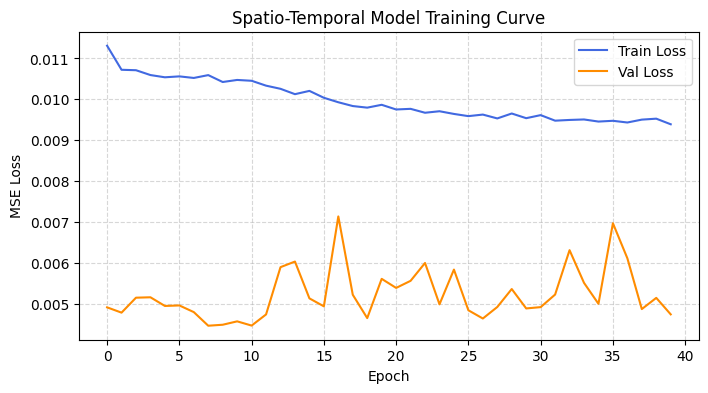

In [15]:
# ==========================================
# 2. TRAINING THE SPATIO-TEMPORAL MODEL
# ==========================================

# Reorder the traffic windows from (time, nodes, features) to (nodes, time, features)
# so they match the wrapper input shape: (batch, nodes, seq_len, input_dim)
x_train_traffic_model = np.transpose(x_train_traffic, (0, 2, 1, 3))
x_test_traffic_model = np.transpose(x_test_traffic, (0, 2, 1, 3))

# Build torch datasets and loaders
train_dataset = torch.utils.data.TensorDataset(
    torch.tensor(x_train_traffic_model, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
test_dataset = torch.utils.data.TensorDataset(
    torch.tensor(x_test_traffic_model, dtype=torch.float32),
    torch.tensor(y_test, dtype=torch.float32)
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=16, shuffle=False)

# Instantiate the model
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SpatioTemporalWrapper(
    num_nodes=num_nodes_spatial,
    output_dim=forecast_steps,
    input_dim=num_features_spatial,
    d_model=64,
    nhead=4,
    num_transformer_layers=1,
    hidden_dim=64,
    num_lstm_layers=1,
    seq_len=lookback,
    dropout=0.1,
).to(DEVICE)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

hist_train = []
hist_val = []

print(f"Training on {DEVICE}...")
epochs = 40
for epoch in range(epochs):
    model.train()
    train_loss = 0.0

    for x_batch, y_batch in train_loader:
        x_batch = x_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        preds = model(x_batch)
        loss = criterion(preds, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        train_loss += loss.item() * x_batch.size(0)

    train_loss /= len(train_dataset)
    hist_train.append(train_loss)

    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch = x_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)
            preds = model(x_batch)
            loss = criterion(preds, y_batch)
            val_loss += loss.item() * x_batch.size(0)

    val_loss /= len(test_dataset)
    hist_val.append(val_loss)

    print(f"Epoch {epoch + 1:02d}/{epochs} | Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}")

plt.figure(figsize=(8, 4))
plt.plot(hist_train, label="Train Loss", color="royalblue")
plt.plot(hist_val, label="Val Loss", color="darkorange")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Spatio-Temporal Model Training Curve")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [ ]:
# ==========================================
# 3. EVALUATION AND INTERACTIVE GRAPHING
# ==========================================
def evaluate_and_plot(model, test_loader, seq_len, output_dim, node_names=None, device="cpu"):
    model.to(device)
    model.eval()

    all_preds = []
    all_trues = []

    with torch.no_grad():
        for x_batch, y_batch in test_loader:
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_trues.append(y_batch.cpu().numpy())

    all_preds = np.concatenate(all_preds, axis=0)
    all_trues = np.concatenate(all_trues, axis=0)

    # The spatio-temporal wrapper now outputs one global forecast horizon per sample.
    # Therefore, the evaluation should report global metrics rather than per-node metrics.
    if all_preds.ndim == 3:
        flat_preds = all_preds.reshape(-1, all_preds.shape[-1])
        flat_trues = all_trues.reshape(-1, all_trues.shape[-1])
    else:
        flat_preds = all_preds
        flat_trues = all_trues

    mae = mean_absolute_error(flat_trues.flatten(), flat_preds.flatten())
    rmse = np.sqrt(mean_squared_error(flat_trues.flatten(), flat_preds.flatten()))
    r2 = r2_score(flat_trues.flatten(), flat_preds.flatten())

    ground_truth_mean = np.mean(flat_trues)
    mae_percentage = mae / ground_truth_mean if ground_truth_mean != 0 else np.nan
    rmse_percentage = rmse / ground_truth_mean if ground_truth_mean != 0 else np.nan

    metrics_df = pd.DataFrame([
        {
            "Metric": "Global Forecast",
            "MAE": round(mae, 4),
            "RMSE": round(rmse, 4),
            "R² Score": round(r2, 4),
            "MAE%": round(mae_percentage, 4),
            "RMSE%": round(rmse_percentage, 4),
        }
    ])

    print("\n================= SPATIO-TEMPORAL METRICS =================")
    print(metrics_df.to_string(index=False))

    # --- Plotly Interactive Node Selector Graph ---
    # Keep the plot for visual inspection, but now it compares one global forecast horizon.
    sample_idx = 0
    fig = go.Figure()
    fig.add_trace(go.Scatter(
        x=list(range(seq_len, seq_len + output_dim)),
        y=flat_trues[sample_idx],
        name="True Horizon",
        mode="lines+markers"
    ))
    fig.add_trace(go.Scatter(
        x=list(range(seq_len, seq_len + output_dim)),
        y=flat_preds[sample_idx],
        name="Predicted Horizon",
        line=dict(dash="dash", color="firebrick"),
        mode="lines+markers"
    ))

    fig.update_layout(
        title="Spatio-Temporal Horizon Evaluation",
        xaxis_title="Time Steps (Hours)",
        yaxis_title="Value Concentration / Scale",
        template="plotly_white",
        height=550,
        showlegend=True
    )

    fig.add_vline(x=seq_len - 0.5, line_width=2, line_dash="dash", line_color="gray")
    fig.show()

    return metrics_df


In [17]:
evaluate_and_plot(model, test_loader, seq_len=lookback, output_dim=forecast_steps, device=DEVICE)


================= SPATIO-TEMPORAL METRICS =================
         Metric    MAE   RMSE  R² Score  MAE%  RMSE%
Global Forecast 0.0529 0.0688   -0.0583 0.498 0.6486


,Metric,MAE,RMSE,R² Score,MAE%,RMSE%
0,Global Forecast,0.0529,0.0688,-0.0583,0.498,0.6486
